# Problem Statement: 
We aim to solve 1D usteady wave equation using the Physics-Informed Neural Networks (PINN). We will obtain a transient solution with a specified wave velocity and prescribed initial and boundary conditions.



### **Domain**:
$$ 
\Omega = \{ (x, t) \mid 0 \leq x \leq \pi, \, 0 \leq t \leq 2\pi \}
$$



### **Governing Equation**:
$$ 
\frac{\partial^2 u}{\partial t^2} - c^2 \frac{\partial^2 u}{\partial x^2} = 0, \quad x \in [0,\pi], t \in [0, 2\pi].
$$ 


### **Boundary Conditions**

**Boundary Conditions** (Prescribed velocity on left and right boundaries):  

   $$ 
   u(0,t) = 0, \: u(\pi,t) = 0 \quad \forall t \in [0, 2\pi].
   $$

**Initial Conditions** (Initial conditions for $u$ and $u_t$):  
   $$ 
   u(x, 0) = sin(x), \quad \forall x \in [0, \pi].
   $$
  
   $$ 
   \frac{\partial u}{\partial x}(x,0) = c\: sin(x), \quad \forall x \in [0, \pi].
   $$

We solve this problem using Physics-Informed Neural Networks (PINN) and compare it with the Analytical solution for this configuration. The objective is to show how to solve transient problems and apply the concept of causality.



---


**Developed by**:
Lal Mamud, Postdoc - Subsurface Modeler, Environmental Subsurface Science Group, Energy & Environment Division, Pacific Northwest National Laboratory, Richland, WA, USA.

Pratanu Roy, Staff Scientist, Atmospheric, Earth and Energy Division, Lawrence Livermore National Laboratory, California, USA
**Mentors**:
Maruti K. Mudunuru and Satish Karra


## 1. Import required Python libraries 

In [1]:
import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
from jax import random, jit, grad, vmap, jacfwd, jacrev
import optax
from jaxopt import LBFGS
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## 2. Define Domain and Boundary Conditions, and Generate Collocation Points

In [2]:
xmin, xmax = 0.0, np.pi
tmin, tmax = 0.0 , 2*np.pi

# Define the boundary conditions
# dT_dx1 = 0             # at x = 0 for all y_b1, Neumann boundary at the left (kPa)  
# T1 = 0             # at x = 1 for all y, Dirichlet boundary at the right (kPa)
# dT_dy1 = 0           # at y = 0 for all x, Neumann boundary at the bottom (kPa)
# T0 = 1.0           # at y = 1 for all x, Dirichlet boundary at the top (kPa)

# define the number of points on each boundary and 
nxb = 101          # Number of initial condition points.
N_r = 5000        # Number of collocation points within the domain

# Number of collocation points in x and y 

nx = 1001
nt = 1001

#domain = random.uniform(key, shape=(nx,ny), dtype='float32',minval=xmin, maxval=xmax)

key = random.PRNGKey(42)

x = random.uniform(key, shape=(nx,), dtype='float32', minval=xmin, maxval=xmax)
t = random.uniform(key, shape=(nt,), dtype='float32', minval=tmin, maxval=tmax)

#x = jnp.linspace(xmin, xmax, nx)
#y = jnp.linspace(ymin, ymax, ny)

xp, tp = jnp.meshgrid(x, t)
colloc = jnp.stack([xp.flatten(), tp.flatten()], 1)

# xin = colloc[:,0]
# yin = colloc[:,1]

# Inputs for initial and boundary condition
xb = random.uniform(key, shape=(nx,), dtype='float32', minval=xmin, maxval=xmax)
t0 = jnp.stack([xb, jnp.ones(nx)*tmin], 1)  

# wave velocity
cvel = 1.0


In [3]:
# def plot_boundary_conditions(x_b1, y_b1, bc_1, x_b2, y_b2, bc_2, x_b3, y_b3, bc_3, x_b4, y_b4, bc_4, x_c, y_c):
#     plt.figure(figsize=(5, 4), dpi=150)
    
#     # Calculate vmin and vmax based on all boundary condition values
#     all_bc_values = np.concatenate([bc_1, bc_2, bc_3, bc_4])
#     vmin, vmax = all_bc_values.min(), all_bc_values.max()
    
#     # Plot each set of boundary conditions with dynamic vmin and vmax
#     s = 10
#     scatter1 = plt.scatter(x_b1, y_b1, c=bc_1, marker='x', vmin=vmin, vmax=vmax, label='P[0,y]', cmap=cm.jet, s=s)
#     plt.scatter(x_b2, y_b2, c=bc_2, marker='^', vmin=vmin, vmax=vmax, label='P[1,y]', cmap=cm.jet, s=s)
#     plt.scatter(x_b3, y_b3, c=bc_3, marker='*', vmin=vmin, vmax=vmax, label='$\\partial P/\\partial y[x,0]$', cmap=cm.jet, s=s)
#     plt.scatter(x_b4, y_b4, c=bc_4, marker='o', vmin=vmin, vmax=vmax, label='$\\partial P/\\partial y[x,1]$', cmap=cm.jet, s=s)
    
#     # Plot collocation points
#     s = 5
#     plt.scatter(x_c, y_c, c='k', marker='.', alpha=0.5, label='Collocation points', s=s)
    
#     # Labels and colorbar
#     plt.xlabel('$X$')
#     plt.ylabel('$Y$')
#     cbar = plt.colorbar(scatter1, aspect=30)  # Attach colorbar to the first scatter plot
#     cbar.set_label('$temperature (kPa)$')
    
#     # Place the legend outside the plot
#     plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
#     plt.tight_layout()

# Call the updated function
# plot_boundary_conditions(x_b1, y_b1, bc_1, x_b2, y_b2, bc_2, x_b3, y_b3, bc_3, x_b4, y_b4, bc_4, x_c, y_c)

## 3. Define PDE Residual

In [4]:
# ∂^2u/∂t^2 -c^2 ∂^2u/∂x^2 = 0 
def pde_residual_2d_darcy(x,t,u):
    """
    Compute the PDE residual for the 2D Laplace equation.
    
    Inputs:
    x, t: Coordinates of collocation points (N x 1).
    u: Lambda function representing the neural network solution u(x, y).
    
    Output:
    Residual of the PDE at the collocation points (N x 1).
    """
    u_x = lambda x,t:jax.grad(lambda x,t:jnp.sum(u(x,t)),0)(x,t)
    u_xx = lambda x,t:jax.grad(lambda x,t:jnp.sum(u_x(x,t)),0)(x,t)
    
    u_t=lambda x,t:jax.grad(lambda x,t:jnp.sum(u(x,t)),1)(x,t)
    u_tt=lambda x,t:jax.grad(lambda x,t:jnp.sum(u_t(x,t)),1)(x,t)

    ic1 = u(t0[:,[0]],t0[:,[1]]).reshape(-1,1) - jnp.sin(t0[:,[0]]).reshape(-1,1)
    ic2 = u_t(t0[:,[0]],t0[:,[1]]).reshape(-1,1) - cvel*jnp.sin(t0[:,[0]]).reshape(-1,1)

    
    return u_xx(x,t) - cvel**2*u_tt(x,t), ic1, ic2

## 4. Define Neural Network Architecture

In [5]:
#Define Neural Network Architecture 
def neural_net(params, x, y):
    """
    Forward pass of a neural network to predict P(x, y).
    
    Inputs:
    params: Neural network parameters (list of weights and biases).
    x, y: Input coordinates (N x 1).
    
    Output:
    Predicted P(x, y) values (N x 1).
    """
    #print(np.shape(x), np.shape(y))
    X = jnp.concatenate([x, y],axis=1)
    *hidden,last = params
    for layer in hidden :
        X = jax.nn.tanh(X@layer['W']+layer['B'])
    return X@last['W'] + last['B']


# def neural_net(params, x, y):
#   # A multi-layer perceptron, i.e. a fully-connected neural network.
#   inputs = jnp.array([x,y])
#   for w, b in params:
#     outputs = jnp.dot(inputs, w) + b  # Linear transform
#     inputs = jnp.tanh(outputs) 
#   return outputs


# Function to initialize parameters of the neural network (weights and biases)
def init_params(layers):
    """
    Initialize parameters (weights and biases) for a neural network with specified layers.
    
    Args:
        layers: List of integers representing the number of nodes in each layer.
                For example, [2, 20, 20, 1] creates a network with input layer (2 nodes),
                two hidden layers (20 nodes each), and an output layer (1 node).
    
    Returns:
        params: List of dictionaries containing 'W' (weights) and 'B' (biases) for each layer.
    """
    keys = jax.random.split(jax.random.PRNGKey(0), len(layers) - 1)  # Generate random keys for each layer
    params = list()  # Initialize a list to store layer parameters
    
    for key, n_in, n_out in zip(keys, layers[:-1], layers[1:]):  # Loop through layer dimensions
        lb, ub = -(1 / jnp.sqrt(n_in)), (1 / jnp.sqrt(n_in))  # Xavier initialization bounds
        W = lb + (ub - lb) * jax.random.uniform(key, shape=(n_in, n_out))  # Initialize weights
        B = jax.random.uniform(key, shape=(n_out,))  # Initialize biases
        params.append({'W': W, 'B': B})  # Append layer parameters (weights and biases) to the list
    
    return params  # Return the initialized parameters

## 5. Define Loss Function

In [6]:
@jax.jit
def loss_fun(params, colloc):
    """
    Calculate the total loss for the PINN.
    
    Inputs:
        params: Neural network parameters (list of weights and biases).
        colloc: Collocation points for the PDE residual (N x 2).
        conds: Boundary condition data (list of 4 elements, one for each BC).
    
    Output:
        Scalar total loss value.
    """
    x_c, t_c = colloc[:, [0]], colloc[:, [1]]
    #print(np.shape(x_c))
    #print(np.shape(y_c))
    lambda_t = (100.0*(1.0-(t_c-tmin)/(tmax-tmin)) + 1.0).reshape(-1,1)
    u_nn = lambda x, t: neural_net(params, x, t)*(x-xmin)*(x-xmax) 
    
    pde_residual, ic1, ic2 = pde_residual_2d_darcy(x_c, t_c, u_nn)
    pde_loss = jnp.mean(lambda_t*pde_residual**2)
    ic_loss = jnp.mean(ic1**2) + jnp.mean(ic2**2) 
    # Loss at the left and right Dirichlet BCs 
    # dbc_loss = 0
    # for cond in conds[0:2]:
    #     x_b, y_b, u_b = cond[:, [0]], cond[:, [1]], cond[:, [2]]  
    #     #dbc_loss += MSE(P_nn(x_b, y_b), u_b)  # Dirichlet BC loss
    #     dbc_loss += jnp.mean(P_nn(x_b, y_b) - u_b)**2  # Dirichlet BC loss
    
    # # Loss at the bottom and top Neumann BCs 
    # nbc_loss = 0
    # P_nn_y = lambda x, y: jax.grad(lambda x, y: jnp.sum(P_nn(x, y)), 1)(x, y)  # Neumann BCs derivative
    # for cond in conds[2:4]:
    #     x_b, y_b, u_b = cond[:, [0]], cond[:, [1]], cond[:, [2]]  
    #     #nbc_loss += MSE(P_nn_y(x_b, y_b), u_b)  # Neumann BC loss
    #     nbc_loss += jnp.mean(P_nn_y(x_b, y_b) - u_b)**2  # Neumann BC loss
    
    # Total loss (summed components)
    #loss = pde_loss + dbc_loss + nbc_loss
    loss = pde_loss + ic_loss
    
    return loss

## 6. Define Hyperparameters and Training Loop
This cell contains the training loop for the Physics-Informed Neural Network (PINN). It includes functions and code to update the network parameters, compute the loss, track training progress, and identify the best-performing model during the training process.

In [15]:
# Define hyperparameters for the neural network and training
hidden_nodes = 32      # Number of nodes in each hidden layer
hidden_layers = 4      # Number of hidden layers in the neural network
lr = 5e-3              # Learning rate for the optimizer
epochs = 20000          # Number of epochs for training
epochs_lbfgs = 100
batch_size = 24

# Construct the MLP (Multilayer Perceptron) using the specified architecture
params = init_params([2] + [hidden_nodes] * hidden_layers + [1])  
# The network has 2 input nodes, `hidden_layers` layers with `hidden_nodes`, and 1 output node.

# Define the optimizer (Adam optimizer with the specified learning rate)
optimizer = optax.adam(lr)

# Initialize the optimizer state using the network parameters
opt_state = optimizer.init(params)


# Parameters update function
@jax.jit
def update(opt_state,params,colloc):
    """
    Perform a single optimization step:
    - Calculate gradients of the loss with respect to network parameters.
    - Update the parameters using the optimizer.
    
    Inputs:
    opt_state: Current optimizer state.
    params: Current neural network parameters (weights and biases).
    colloc: Collocation points for the PDE residual loss.
    conds: Boundary condition data for Dirichlet and Neumann conditions.
    
    Outputs:
    opt_state: Updated optimizer state.
    params: Updated network parameters.
    """
    # Get the gradient w.r.t to MLP params
    #grads=jax.jit(jax.grad(loss_fun,0))(params,colloc)
    value, grads = jax.value_and_grad(loss_fun)(params, colloc)
    
    #Update params
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return opt_state, params


@jax.jit
def update_lbfgs(params, colloc):
    """ Compute the gradient for a batch and update the parameters using bfgs """
    solver = LBFGS(fun=loss_fun, value_and_grad=False, has_aux=False, maxiter=500, tol=1e-6, stepsize=0.0)
    res = solver.run(params, colloc)
    #params, opt_state = res
    return res.params

#%% PINN training loop
print('PINN training started...')

# Initialize tracking variables
best_params = params
best_loss = float('inf')
best_epoch = 0

# Initialize lists to track all losses and epochs
all_losses = []
all_epochs = []

# Training loop
for epoch in range(epochs+1):
    # Update the optimizer state and parameters
    colloc_batched = colloc[np.random.choice(colloc.shape[0], size=batch_size)]
    #opt_state, params = update(opt_state, params, colloc)
    opt_state, params = update(opt_state, params, colloc_batched)

    # Calculate the current loss
    current_loss = loss_fun(params, colloc_batched)
    
    # Store loss and epoch
    all_losses.append(current_loss)
    all_epochs.append(epoch)
    
    # Update the best parameters if the current loss is the lowest
    if current_loss < best_loss:
        best_loss = current_loss
        best_params = params
        best_epoch = epoch

    # Print loss and epoch info
    if epoch % 1000 == 0:
        print(f'Epoch={epoch}\tloss={current_loss:.3e}')

# Training loop
# for epoch in range(epochs_lbfgs+1):
#     # Update the optimizer state and parameters
#     colloc_batched = colloc[np.random.choice(colloc.shape[0], size=batch_size)]
#     #opt_state, params = update(opt_state, params, colloc)
#     opt_state, params = update_lbfgs(params, colloc_batched)

#     # Calculate the current loss
#     current_loss = loss_fun(params, colloc_batched)
    
#     # Store loss and epoch
#     all_losses.append(current_loss)
#     all_epochs.append(epoch)
    
#     # Update the best parameters if the current loss is the lowest
#     if current_loss < best_loss:
#         best_loss = current_loss
#         best_params = params
#         best_epoch = epoch

#     # Print loss and epoch info
#     if epoch_lbfgs % 10 == 0:
#         print(f'Epoch={epoch}\tloss={current_loss:.3e}')


print('PINN training done!')
print(f'Best Epoch = {best_epoch}\tBest Loss = {best_loss:.3e}')

PINN training started...
Epoch=0	loss=2.349e+00
Epoch=1000	loss=1.233e-01
Epoch=2000	loss=2.650e-02
Epoch=3000	loss=2.052e-01
Epoch=4000	loss=1.418e-01
Epoch=5000	loss=1.443e-01
Epoch=6000	loss=1.756e-01
Epoch=7000	loss=1.664e-01
Epoch=8000	loss=1.786e-01
Epoch=9000	loss=1.588e-01
Epoch=10000	loss=2.051e-02
Epoch=11000	loss=3.229e-02
Epoch=12000	loss=8.592e-03
Epoch=13000	loss=1.666e-02
Epoch=14000	loss=5.875e-03
Epoch=15000	loss=8.577e-03
Epoch=16000	loss=1.141e-01
Epoch=17000	loss=2.552e-01
Epoch=18000	loss=2.996e-03
Epoch=19000	loss=8.192e-02
Epoch=20000	loss=5.041e-03
PINN training done!
Best Epoch = 17954	Best Loss = 1.455e-03


## 7. Plot pinn loss during training

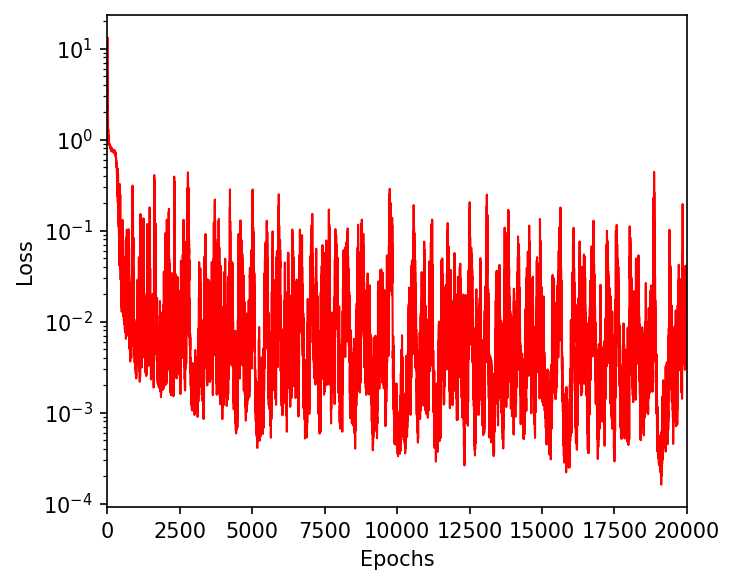

In [8]:
#function for plotting for PINN losses during training 
def plot_pinn_training(all_losses, all_epochs):
    plt.figure(figsize = (5, 4), dpi = 150)
    plt.semilogy(all_epochs, all_losses, '-r', markersize = 4, linewidth = 1.0)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    #plt.legend(prop={"size": fontsize_legend}, loc="best")
    plt.xlim(min(all_epochs), max(all_epochs))
    plt.tight_layout()
    
plot_pinn_training(all_losses, all_epochs)

## 8. PINN prediction and plotting results

In [9]:
#%% PINN prediction and plotting results
nx = 50
x = np.linspace(xmin, xmax, nx)
dx = x[1] - x[0]
nt = 50
y = np.linspace(tmin, tmax, nt)
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
print(np.shape(X), np.shape(Y))
pinn_T = (neural_net(best_params, X.flatten().reshape(-1,1), Y.flatten().reshape(-1,1))).reshape(nx,nt) 
print(np.shape(pinn_T))
#print(pinn_T)

(50, 50) (50, 50)
(50, 50)


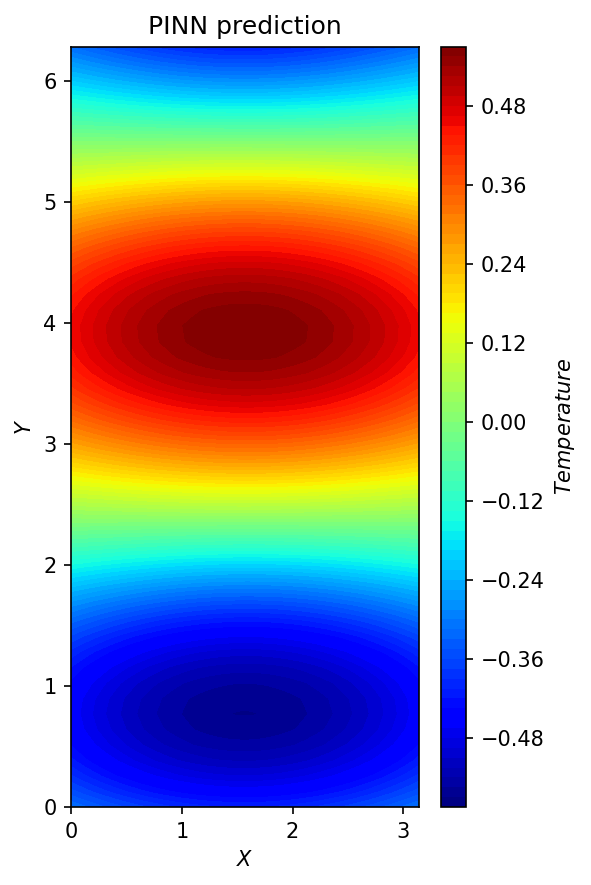

In [10]:
def plot_2d_temperature_distribution(X, Y, temperature, title, cbar_lebel):
    plt.figure(figsize = (4, 6), dpi = 150)
    cmap = 'jet'
    contour = plt.contourf(X, Y, temperature, levels=100, cmap=cmap)  
    plt.xlabel('$X$')
    plt.ylabel('$Y$')
    # Colorbar settings
    vmin = np.min(temperature)
    vmax = np.max(temperature)
    #cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin = vmin, vmax = vmax), cmap=cm.jet), aspect=30)
    cbar = plt.colorbar(contour, aspect=30)


    cbar.set_label(f'{cbar_lebel}')
    plt.xlim(np.min(X), np.max(X))
    plt.ylim(np.min(Y), np.max(Y))
    plt.title(title)
    plt.tight_layout()

title = "PINN prediction"
cbar_lebel = "$Temperature$"
plot_2d_temperature_distribution(X, Y, pinn_T, title, cbar_lebel)

## 9. Solution verifications

In [11]:
#%% Analytical solution
def f_exact(x,t,cvel): 
  return jnp.sin(x)*(jnp.sin(cvel*t)+jnp.cos(cvel*t))

analytical_T = f_exact(X,Y,cvel)
#print(analytical_P)

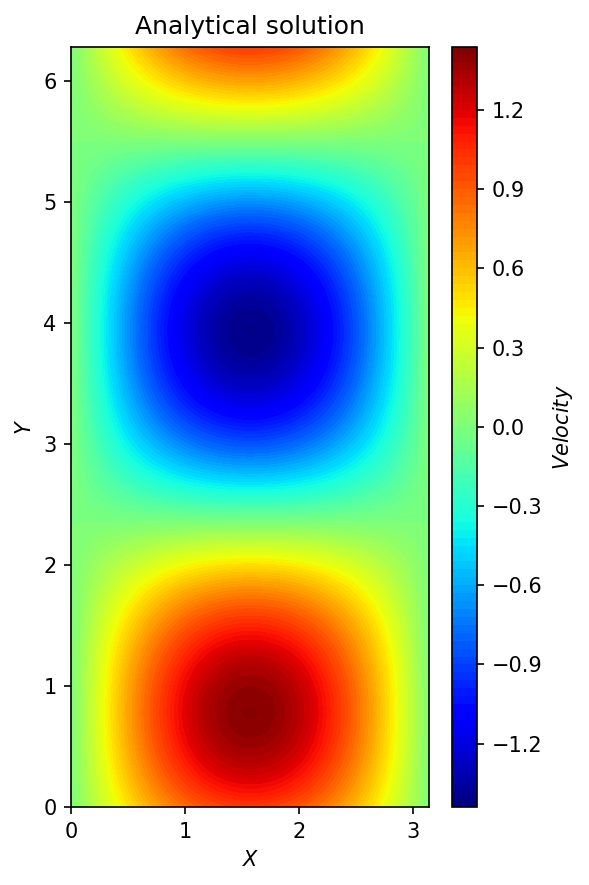

In [12]:
title = "Analytical solution"
cbar_lebel = "$Velocity$"
plot_2d_temperature_distribution(X, Y, analytical_T, title, cbar_lebel)

## 10. Error analysis between the analytical solution and PINN prediction

(2500, 1) (2500, 1)
R^2 Score: 0.8493
Root Mean Squared Error (RMSE): 0.1454


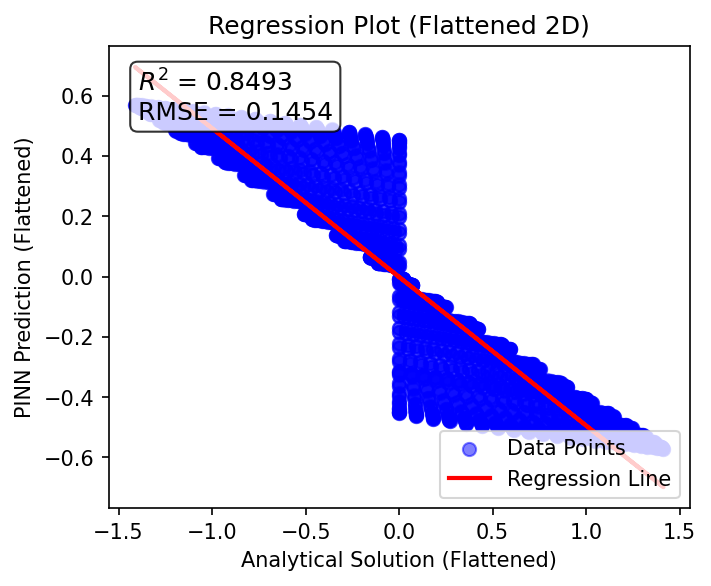

In [13]:
# Flatten the 2D arrays into 1D
analytical_Tr = analytical_T.flatten().reshape(-1, 1)  # Flatten to 1D and reshape to 2D (n_samples, n_features)
pinn_Tr = pinn_T.flatten().reshape(-1, 1)                       # Flatten to 1D (n_samples,)

print(np.shape(analytical_Tr), np.shape(pinn_Tr))
# Perform regression
reg = LinearRegression()
reg.fit(analytical_Tr, pinn_Tr)  # Fit the model

# Predict using the regression model
y_pred = reg.predict(analytical_Tr)

# Calculate R^2 score
r2 = r2_score(pinn_Tr, y_pred)

# Calculate RMSE
mse = mean_squared_error(pinn_Tr, y_pred)  # Mean Squared Error
rmse = np.sqrt(mse)  # Root Mean Squared Erro

# Print results
print(f"R^2 Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

#%% Plotting Regression
plt.figure(figsize=(5, 4), dpi = 150)
plt.scatter(analytical_Tr, pinn_Tr, label="Data Points", color="blue", alpha=0.5, s=40)
plt.plot(analytical_Tr, y_pred, label="Regression Line", color="red", linewidth=2)

# Add annotations for RMSE and R^2
plt.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.4f}\nRMSE = {rmse:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.xlabel("Analytical Solution (Flattened)")
plt.ylabel("PINN Prediction (Flattened)")
plt.title("Regression Plot (Flattened 2D)")
plt.legend(loc="lower right")

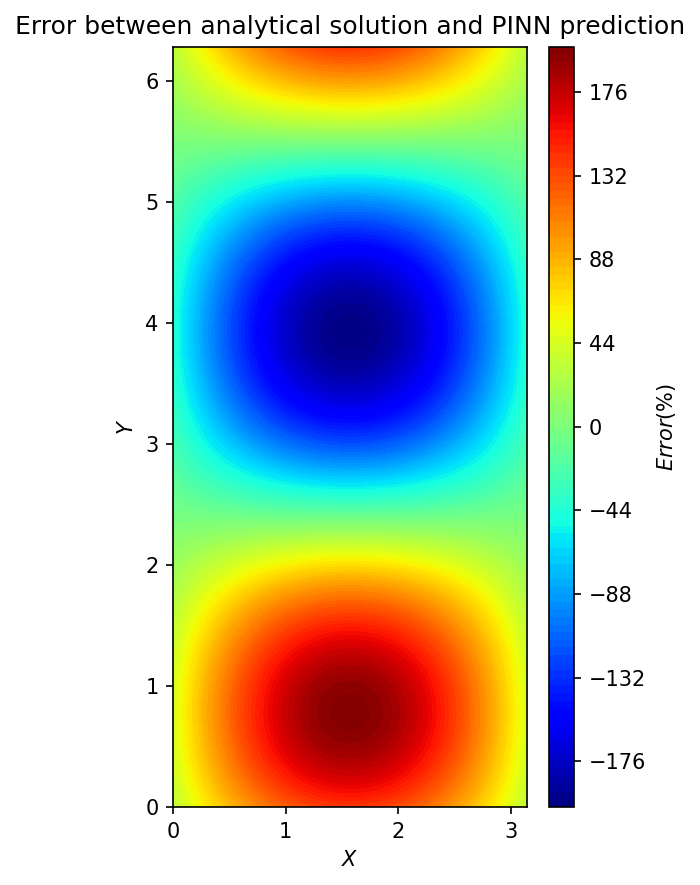

In [14]:
# Plot the percentage error
error_percentage = 100 * (analytical_T - pinn_T)
title = "Error between analytical solution and PINN prediction"
cbar_lebel = "$Error (\%)$"
plot_2d_temperature_distribution(X, Y, error_percentage, title, cbar_lebel)